In [1]:
import math
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display

import glob, re
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [2]:
class Attention(nn.Module):
    def __init__(self, d_model, n_heads, causal=True):
        super().__init__()
        self.n_heads, self.d_head, self.causal = n_heads, d_model // n_heads, causal
        self.W_qkv = nn.Linear(d_model, 3 * d_model, bias=False)
        self.W_o   = nn.Linear(d_model, d_model, bias=False)
    def forward(self, x, return_attn=False):
        B, T, C = x.shape
        q, k, v = self.W_qkv(x).chunk(3, dim=-1)
        q = q.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        k = k.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        v = v.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        scores = (q @ k.transpose(-2, -1)) / math.sqrt(self.d_head)
        if self.causal:                                  # optional causal mask
            mask = torch.triu(torch.ones(T, T, device=x.device, dtype=torch.bool), diagonal=1)
            scores = scores.masked_fill(mask, float('-inf'))
        attn = F.softmax(scores, dim=-1)
        out = (attn @ v).transpose(1, 2).contiguous().view(B, T, C)
        out = self.W_o(out)
        return (out, attn) if return_attn else out

class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, causal=True):
        super().__init__()
        self.ln1, self.attn = nn.LayerNorm(d_model), Attention(d_model, n_heads, causal)
        self.ln2 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(nn.Linear(d_model, d_ff), nn.ReLU(), nn.Linear(d_ff, d_model))
    def forward(self, x, return_attn=False):
        a = self.attn(self.ln1(x), return_attn=return_attn)
        if return_attn:
            a, w = a
        x = x + a
        x = x + self.ffn(self.ln2(x))
        return (x, w) if return_attn else x

class GrokTransformer(nn.Module):
    def __init__(self, p, n_inputs, d_model, n_heads, n_layers, d_ff, causal=True):
        super().__init__()
        self.p, self.seq_len, self.n_layers = p, n_inputs + 1, n_layers
        self.token_emb = nn.Embedding(p + 1,        d_model)
        self.pos_emb   = nn.Embedding(self.seq_len, d_model)
        self.blocks    = nn.ModuleList([TransformerBlock(d_model, n_heads, d_ff, causal) for _ in range(n_layers)])
        self.ln_f      = nn.LayerNorm(d_model)
        self.unembed   = nn.Linear(d_model, p, bias=False)

    def forward(self, x, return_cache=False):
        h = self.token_emb(x) + self.pos_emb(torch.arange(x.size(1), device=x.device))
        if not return_cache:                              # fast path used in training
            for block in self.blocks:
                h = block(h)
            return self.unembed(self.ln_f(h)[:, -1])
        cache = {'embed': h}                              # instrumented path used in analysis
        for i, block in enumerate(self.blocks):
            h, w = block(h, return_attn=True)
            cache[f'resid_post_{i}'] = h
            cache[f'attn_weights_{i}']       = w                  # (B, n_heads, T, T)
        return self.unembed(self.ln_f(h)[:, -1]), cache

# Analysis

The cells below perform an in depth analysis of what happens during the training process

### Finding and loading checkpoint files

In [3]:
#Find and sort all checkpoints by step number:
CKPT_DIR     = './ckpts_causal'         # directory to write .pt files into
PATTERN = os.path.join(CKPT_DIR, 'grok_ckpt_step*.pt') #* is the wildcard, matches anything

#Create list of all filenames matching the pattern, sorted by the key which is the step number in the filename
ckpt_files = sorted(glob.glob(PATTERN), key=lambda f: int(re.search(r'_step(\d+)', f).group(1)))

if not ckpt_files: #If the list is empty raise an error
    raise FileNotFoundError(f'No checkpoints found matching {PATTERN}. '
                            'Run training first or lower SAVE_EVERY.')

print(f'Found {len(ckpt_files)} checkpoint(s):')
for f in ckpt_files: #Print what we found
    print(' ', f)

Found 31 checkpoint(s):
  ./ckpts_causal/grok_ckpt_step0.pt
  ./ckpts_causal/grok_ckpt_step1000.pt
  ./ckpts_causal/grok_ckpt_step2000.pt
  ./ckpts_causal/grok_ckpt_step3000.pt
  ./ckpts_causal/grok_ckpt_step4000.pt
  ./ckpts_causal/grok_ckpt_step5000.pt
  ./ckpts_causal/grok_ckpt_step6000.pt
  ./ckpts_causal/grok_ckpt_step7000.pt
  ./ckpts_causal/grok_ckpt_step8000.pt
  ./ckpts_causal/grok_ckpt_step9000.pt
  ./ckpts_causal/grok_ckpt_step10000.pt
  ./ckpts_causal/grok_ckpt_step11000.pt
  ./ckpts_causal/grok_ckpt_step12000.pt
  ./ckpts_causal/grok_ckpt_step13000.pt
  ./ckpts_causal/grok_ckpt_step14000.pt
  ./ckpts_causal/grok_ckpt_step15000.pt
  ./ckpts_causal/grok_ckpt_step16000.pt
  ./ckpts_causal/grok_ckpt_step17000.pt
  ./ckpts_causal/grok_ckpt_step18000.pt
  ./ckpts_causal/grok_ckpt_step19000.pt
  ./ckpts_causal/grok_ckpt_step20000.pt
  ./ckpts_causal/grok_ckpt_step21000.pt
  ./ckpts_causal/grok_ckpt_step22000.pt
  ./ckpts_causal/grok_ckpt_step23000.pt
  ./ckpts_causal/grok_ckpt_st

In [4]:
def load_ckpt(path): #Function takes im input a path file string and returns a loaded checkpoint dictionary
    ckpt = torch.load(path, map_location='cpu') #loads the .pt file
    step = ckpt['step']
    h    = ckpt['history']
    print(f"  step={step:6d}  train_acc={h['train_acc'][-1]:.3f}  val_acc={h['val_acc'][-1]:.3f}")
    return ckpt

print('Loading all checkpoints...')
ckpts  = [load_ckpt(f) for f in ckpt_files] #ckpts will be a list of dictionaries, one per checkpoint, in cronological order
steps  = [c['step'] for c in ckpts]
print(f'Steps covered: {steps}')

Loading all checkpoints...
  step=     0  train_acc=0.026  val_acc=0.027
  step=  1000  train_acc=1.000  val_acc=0.033
  step=  2000  train_acc=1.000  val_acc=0.117
  step=  3000  train_acc=1.000  val_acc=1.000
  step=  4000  train_acc=1.000  val_acc=1.000
  step=  5000  train_acc=1.000  val_acc=1.000
  step=  6000  train_acc=1.000  val_acc=1.000
  step=  7000  train_acc=1.000  val_acc=1.000
  step=  8000  train_acc=1.000  val_acc=1.000
  step=  9000  train_acc=1.000  val_acc=1.000
  step= 10000  train_acc=1.000  val_acc=1.000
  step= 11000  train_acc=0.996  val_acc=0.996
  step= 12000  train_acc=0.809  val_acc=0.804
  step= 13000  train_acc=1.000  val_acc=1.000
  step= 14000  train_acc=0.326  val_acc=0.318
  step= 15000  train_acc=1.000  val_acc=1.000
  step= 16000  train_acc=0.972  val_acc=0.963
  step= 17000  train_acc=1.000  val_acc=0.999
  step= 18000  train_acc=1.000  val_acc=0.999
  step= 19000  train_acc=0.863  val_acc=0.859
  step= 20000  train_acc=1.000  val_acc=0.999
  step=

### Visualizing training curves

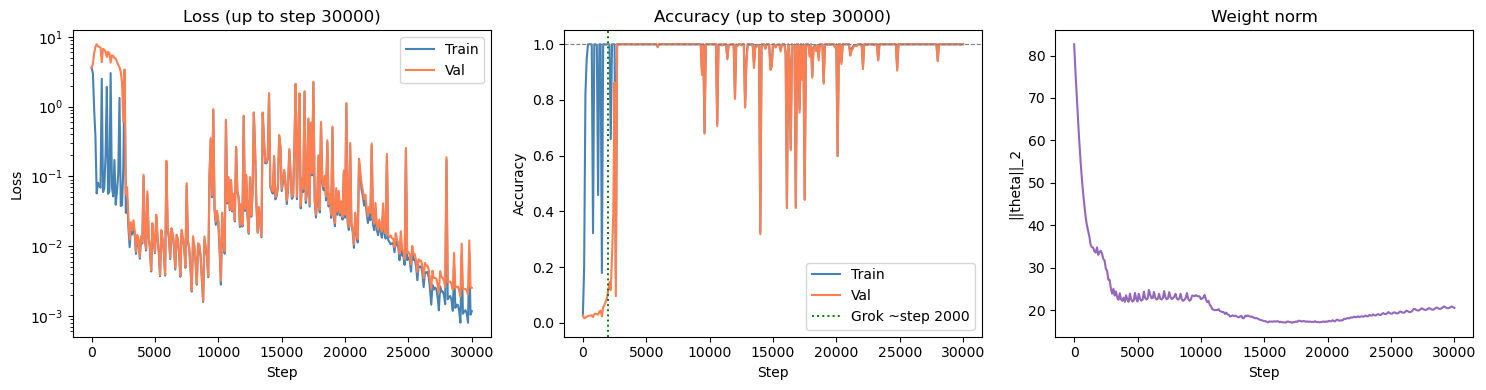

Grokking step: 2000


In [5]:
def plot_training_curves(ckpt): #Takes in input a checkpoint dictionary
    h     = ckpt['history'] #history dictionary with logged values
    steps = h['step']

    fig, axes = plt.subplots(1, 3, figsize=(15, 4)) #3 subplots

    #1st plot: plot train and val loss over time on a log scale
    axes[0].plot(steps, h['train_loss'], label='Train', color='steelblue')
    axes[0].plot(steps, h['val_loss'],   label='Val',   color='coral')
    axes[0].set_yscale('log')
    axes[0].set_xlabel('Step'); axes[0].set_ylabel('Loss')
    axes[0].set_title(f"Loss (up to step {ckpt['step']})")
    axes[0].legend()

    #2st plot: plot train and val accuracy over time
    axes[1].plot(steps, h['train_acc'], label='Train', color='steelblue')
    axes[1].plot(steps, h['val_acc'],   label='Val',   color='coral')
    axes[1].set_xlabel('Step'); axes[1].set_ylabel('Accuracy')
    axes[1].set_title(f"Accuracy (up to step {ckpt['step']})")
    axes[1].set_ylim(-0.05, 1.05)
    axes[1].axhline(1.0, color='grey', linestyle='--', linewidth=0.8)
    #Find the 1st step where validation accuracy exceeds 10%, as a heuristic for when grokking begins.
    grok_step = next((s for s, v in zip(steps, h['val_acc']) if v > 0.10), None)
    if grok_step is not None: #If grokking was detected, draw a vertical line 
        axes[1].axvline(grok_step, color='green', linestyle=':', linewidth=1.4,
                        label=f'Grok ~step {grok_step}')
    axes[1].legend()

    #3rd plot: L2 norm of all parameters over time.
    axes[2].plot(steps, h['weight_norm'], color='#9467bd')
    axes[2].set_xlabel('Step'); axes[2].set_ylabel('||theta||_2')
    axes[2].set_title('Weight norm')

    plt.tight_layout()
    plt.savefig('analysis_curves.png', dpi=150)
    plt.show()
    print(f'Grokking step: {grok_step}')

plot_training_curves(ckpts[-1])

#### Embedding PCA 
Projects the token embedding matrix W_E onto its top 2 principal components
and plots each token 0..36 as a point.\
Before grokking: scattered, no structure.\
After grokking: tokens arrange into a circle or rotational pattern, reflecting the model's discovery of a periodic (Fourier) representation.

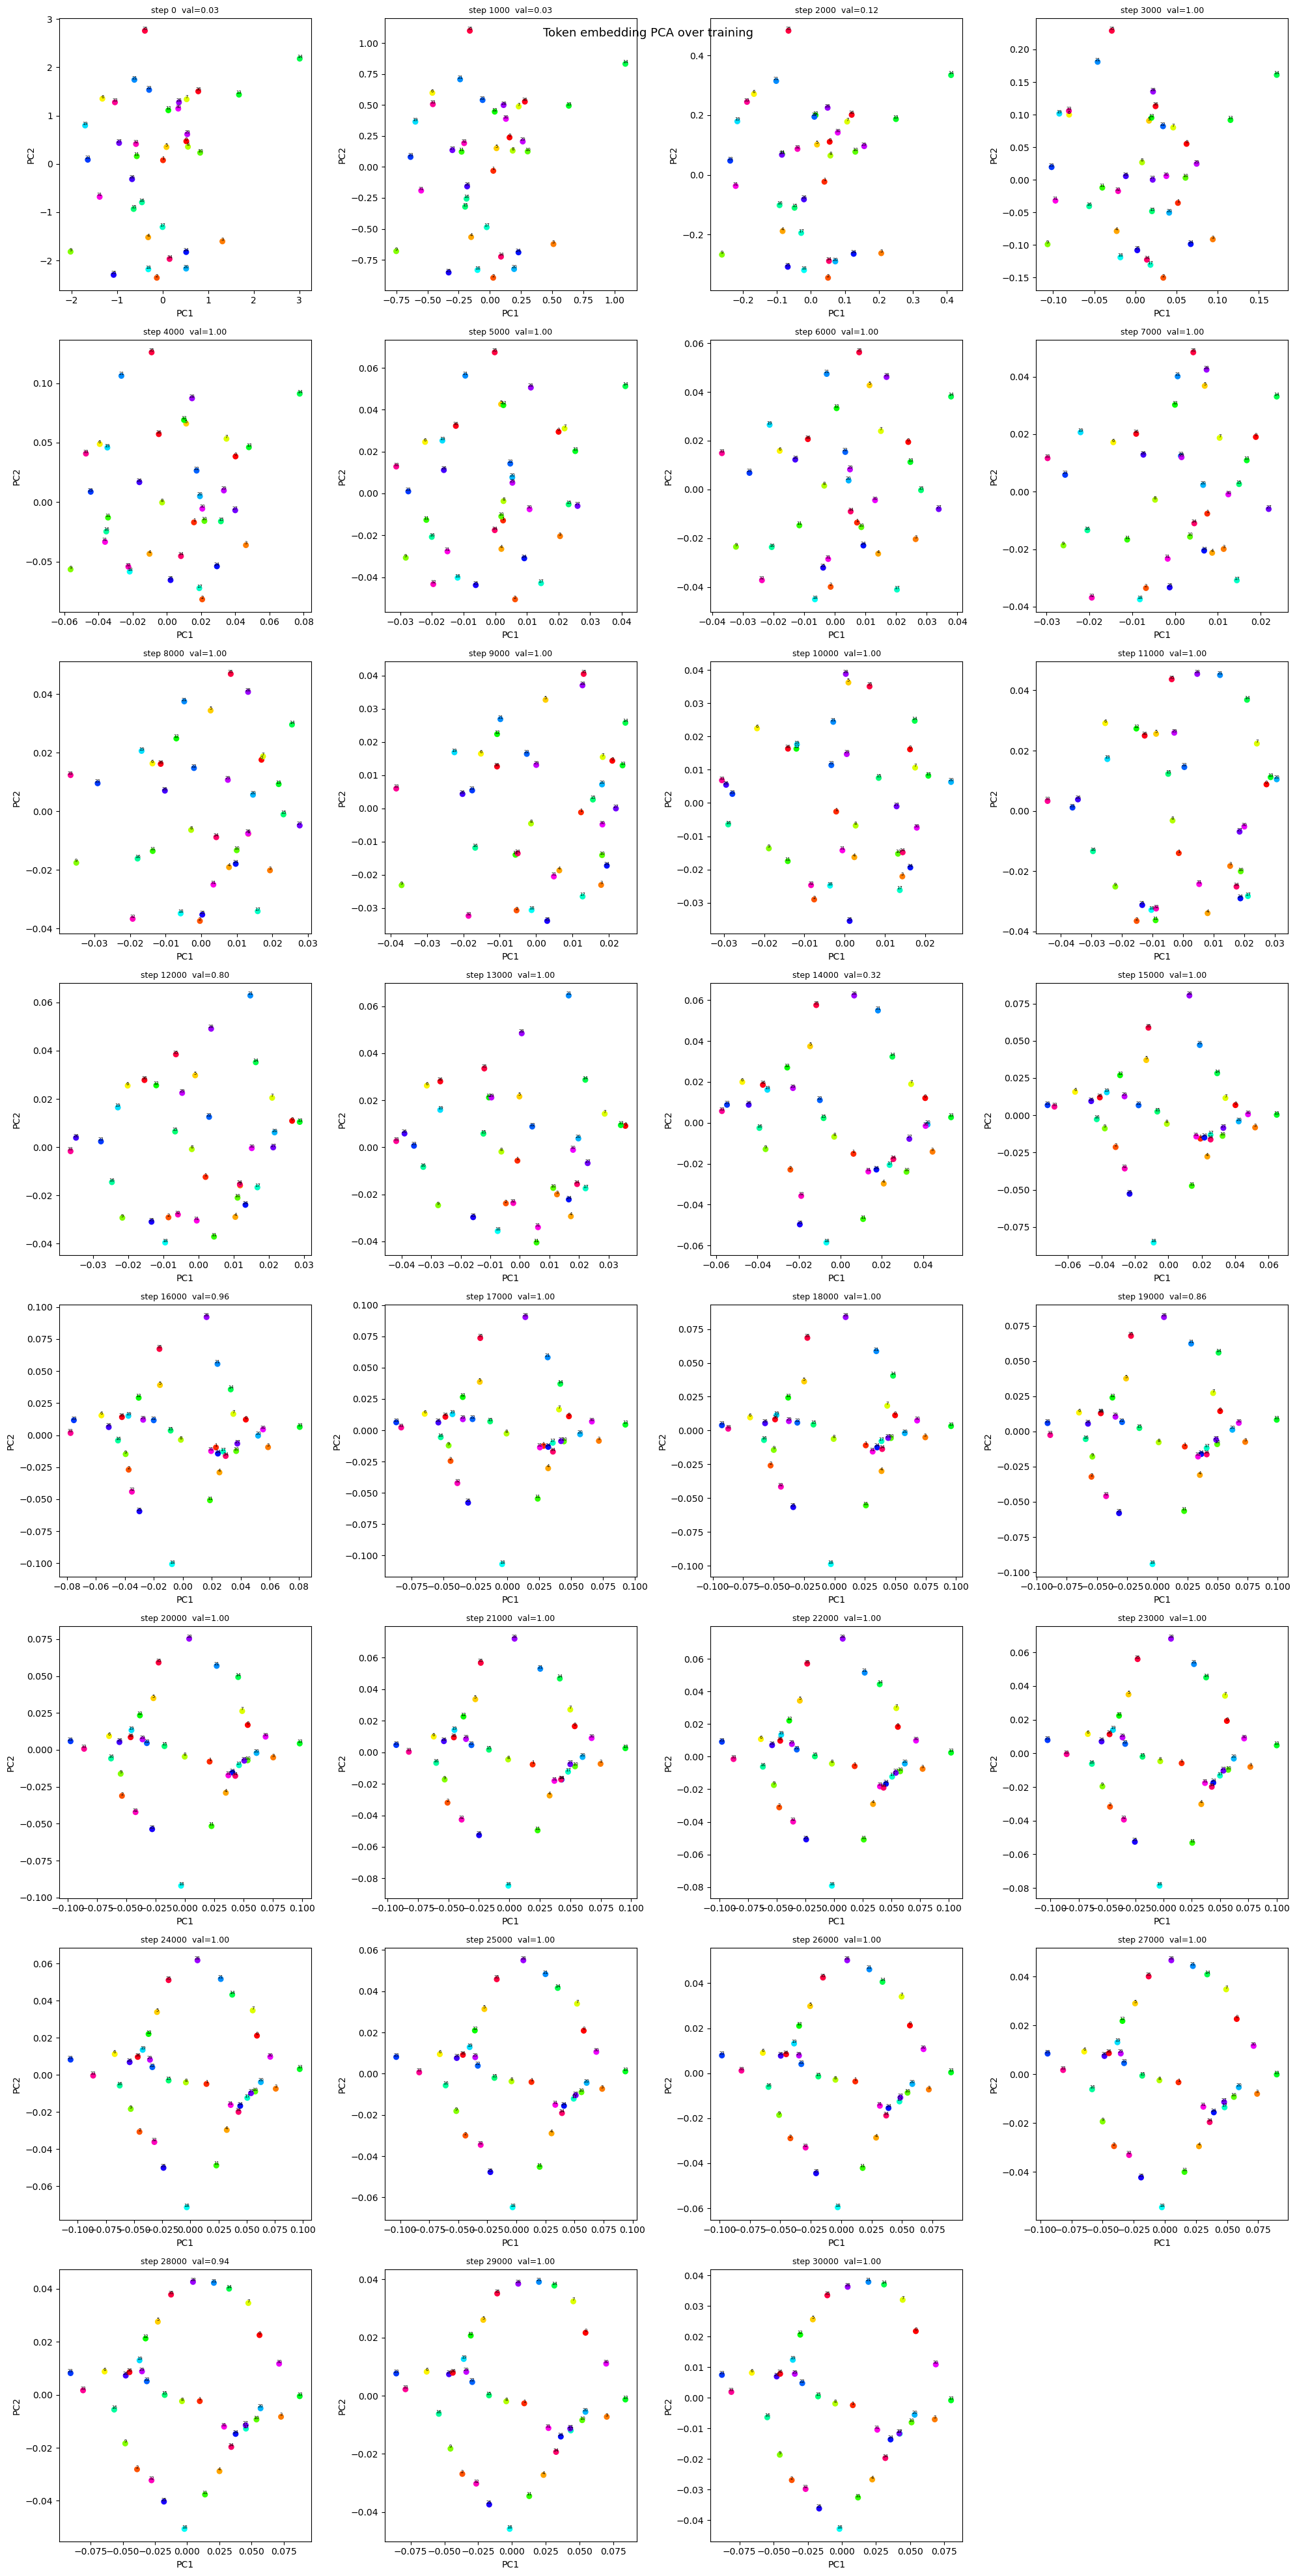

In [6]:
def get_embeddings(ckpt):
    #Extracts the token embedding matrix from the checkpoint. 
    #It's a tensor of shape [38,128], we only get the first 37 because we only want to visualize number tokens
    #Converted to numpy for sklearn and matplotlib
    return ckpt['model_state_dict']['token_emb.weight'].numpy()[:ckpt['config']['p']]

def plot_all_embedding_pcas(ckpts):#Plots the projection of the embedding matrix on the PCA of the last checkpoint's embeddings.
    
    #Compute the grid layout. 
    n    = len(ckpts) 
    cols = min(n, 4)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
    axes = np.array(axes).flatten() #converted to 1D array to iterate over it

    pca = PCA(n_components=2) #Creates a PCA object that will project 128 dim embeddign down to 2 dim
    pca.fit(get_embeddings(ckpts[-1]))  # fit on last ckpt so axes are comparable
    #If we fit it on all checkpoints separately, the axes would rotate and we could not compare them.

    for ax, ckpt in zip(axes, ckpts): #For each checkpoint
        W  = get_embeddings(ckpt) #get embedding matrix
        E2 = pca.transform(W) #project in onto the 2 principal components fitted above, shape [37,2]
        #Plot the 37 points, each token is colored with a circular color map from 0 to 36, so 0 has a similar color to 36
        ax.scatter(E2[:, 0], E2[:, 1], c=np.arange(ckpt['config']['p']), cmap='hsv', s=30, zorder=3)
        for i, (x, y) in enumerate(E2):
            ax.annotate(str(i), (x, y), fontsize=5, ha='center', va='bottom')
        h = ckpt['history']
        ax.set_title(f"step {ckpt['step']}  val={h['val_acc'][-1]:.2f}", fontsize=9)
        ax.set_xlabel('PC1'); ax.set_ylabel('PC2')

    for ax in axes[len(ckpts):]:
        ax.set_visible(False) #Hide unused subplot panels

    plt.suptitle('Token embedding PCA over training', fontsize=13)
    plt.tight_layout()
    plt.savefig('analysis_pca_all.png', dpi=150)
    plt.show()

plot_all_embedding_pcas(ckpts)

#### Embedding Fourier energy 
Projects the token embedding matrix onto normalised Fourier basis vectors and
measures how much energy sits at each frequency k=1..18.\
High energy at k means the embedding vectors oscillate at that rate.\
Key finding: energy is flat before grokking, then collapses into sparse frequencies at the grokking transition.

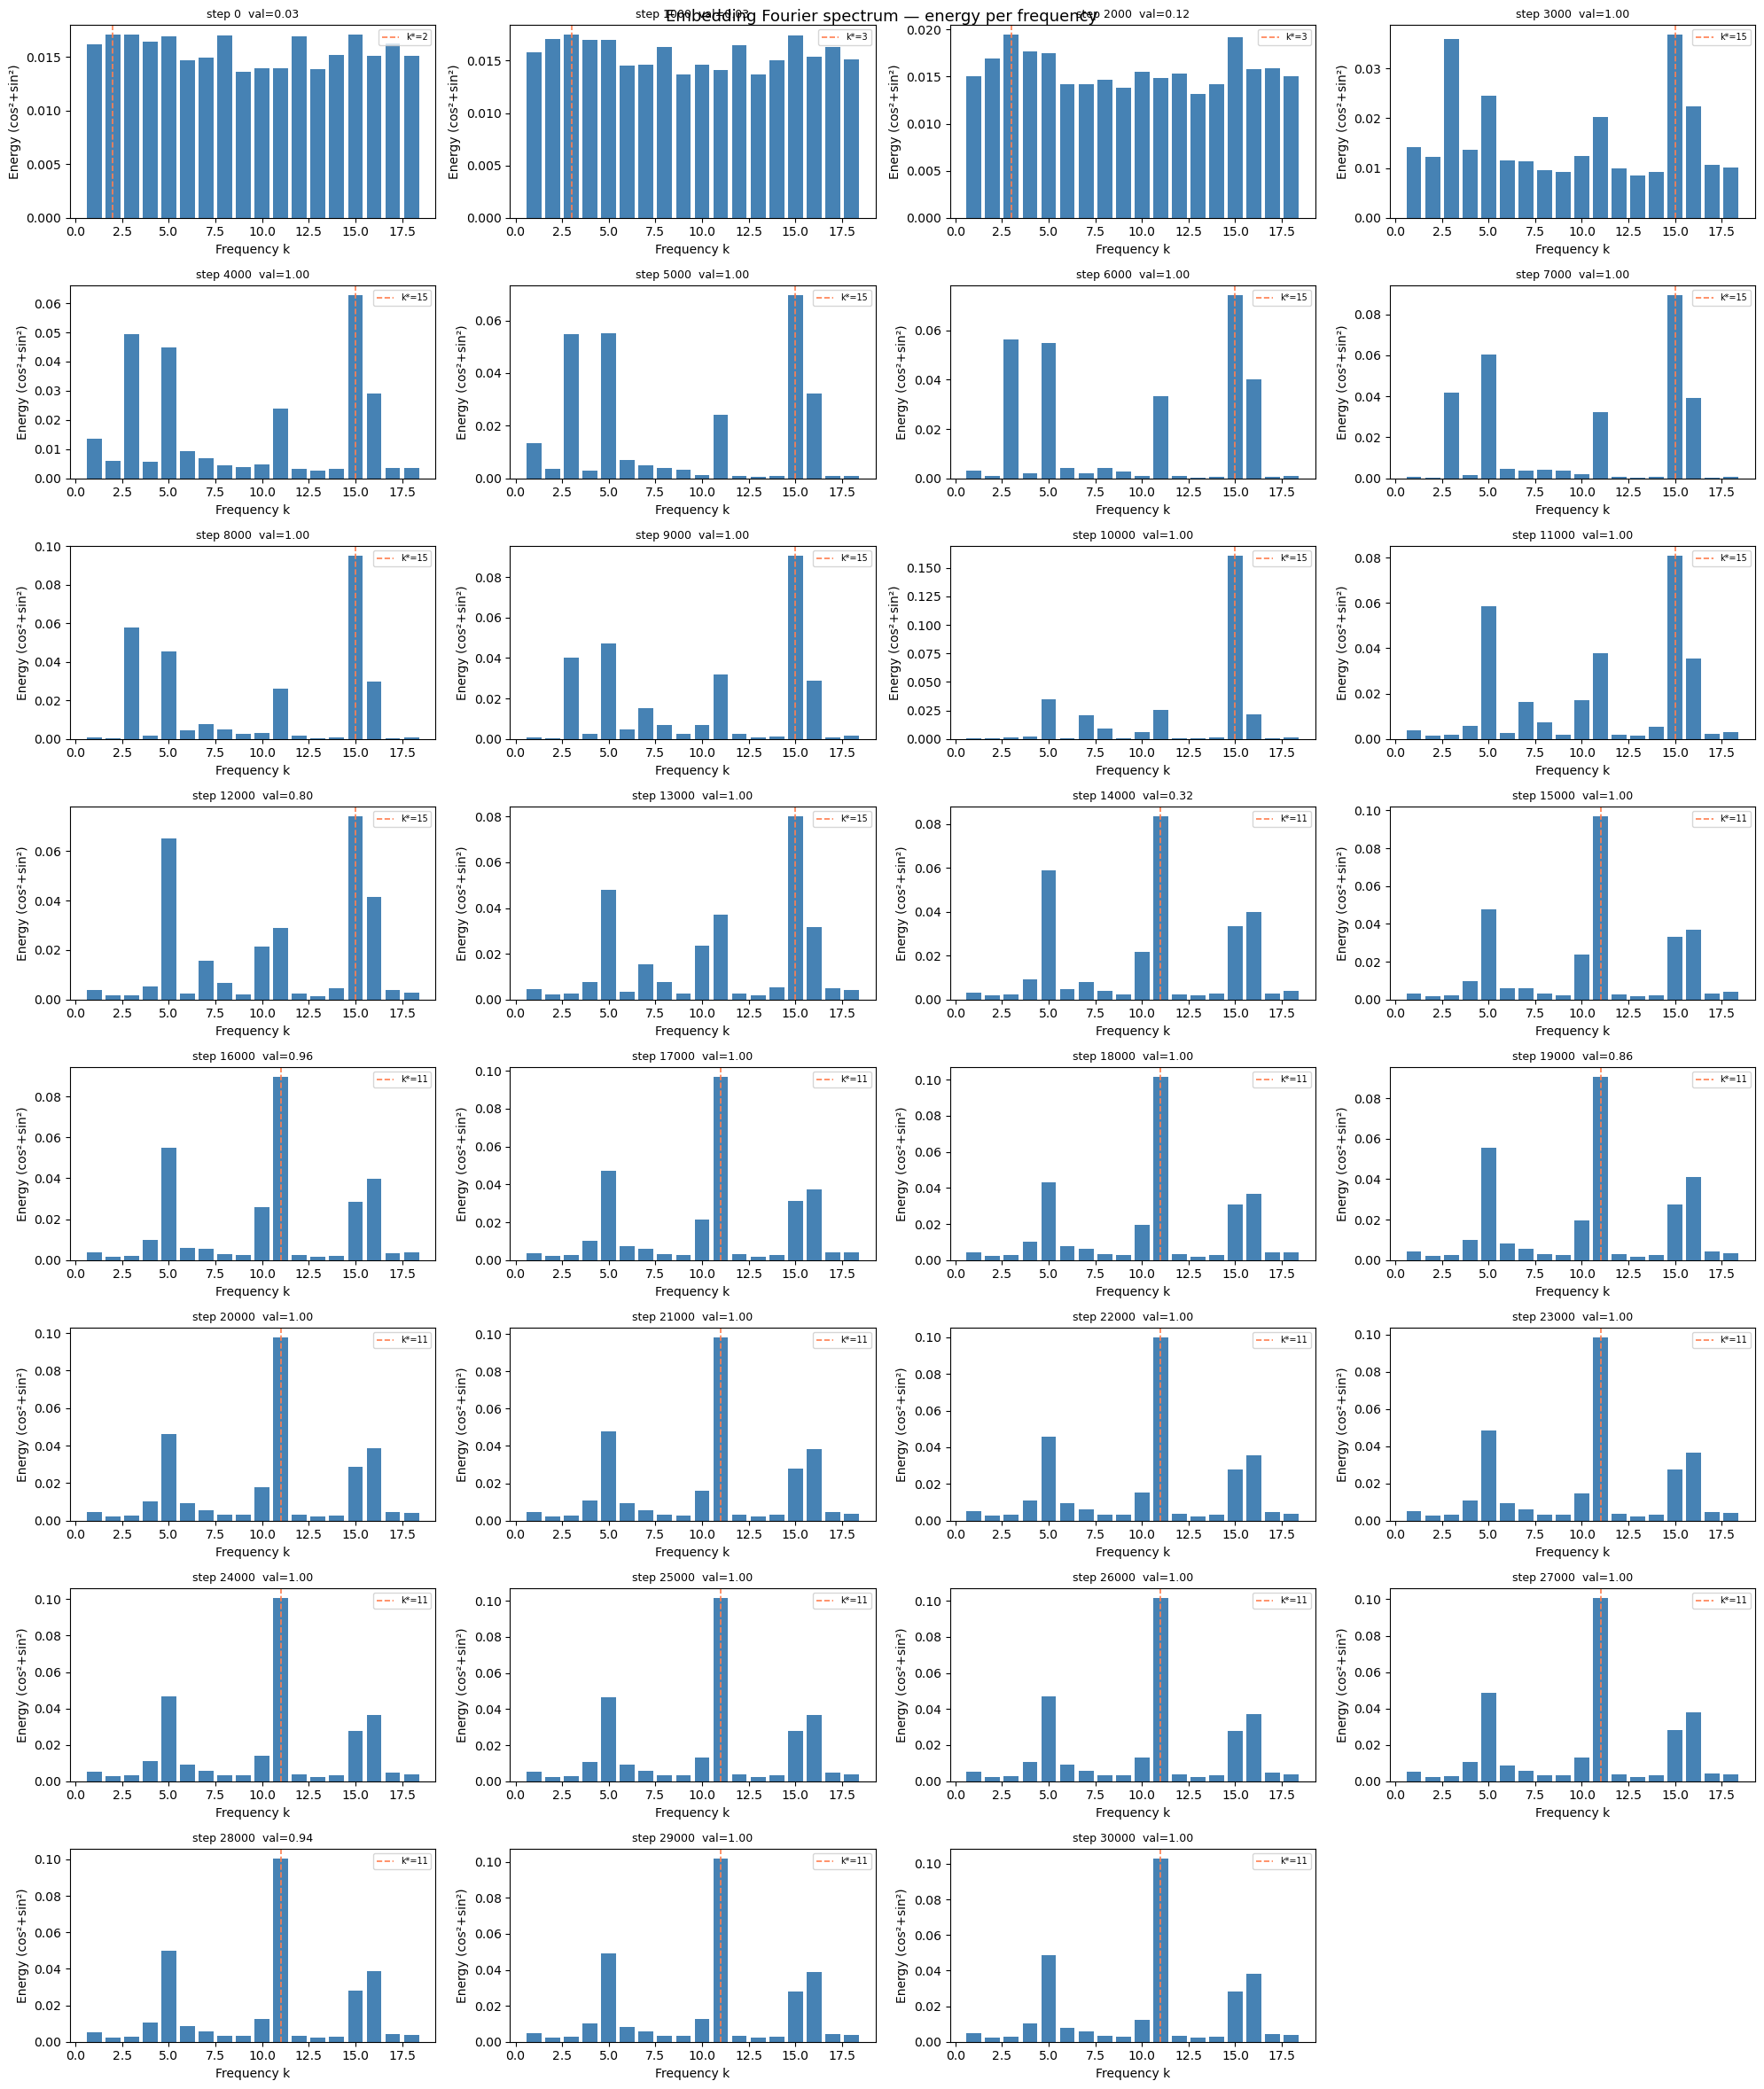

In [7]:
def fourier_basis(p): #Creates the Fourier Basis, each row is a reference wave that represents what a pure sin or cos at frequency k would look like evaluated at all 37 token positions.
    xs    = np.arange(p) #Creates array [0,...,p-1]
    basis = []
    #For each frequency k from 0 to p-1, compute 2 vectors of lenght p
    #One cos and one sin evaluated at all token positions.
    for k in range(p):
        basis.append(np.cos(2 * np.pi * k * xs / p))
        basis.append(np.sin(2 * np.pi * k * xs / p))
    B     = np.stack(basis) #stacks the list of vectors in a 2D matrix of shape [2p,p]
    norms = np.linalg.norm(B, axis=1, keepdims=True) #Normalize each row to unit lenght
    norms[norms == 0] = 1 #set the 0 norms to 1 to avoid numerical issues
    return B / norms

def compute_fourier_energy(ckpt):
    W      = get_embeddings(ckpt)
    W_norm = W / (np.linalg.norm(W, axis=1, keepdims=True) + 1e-8) #We normalize the mebedding matrix because we care about shape not scale
    B      = fourier_basis(ckpt['config']['p']) 
    coeffs = B @ W_norm #B is [74,37], W_norm is [37,128]. coeffs becomes [74,128] 
    #It's the cosine similarty: how much each embedding dimention looks like each fourier wave actoss teh 37 tokens.
    return (coeffs ** 2).mean(axis=1) #Quaring the coefficients and averaging across the 128 embedding dimentions
    #Gives a single energy value per Fourier basis vector: how much the average embedding dimention resembles the wave.

def compute_fourier_energy_by_freq(ckpt):
    raw = compute_fourier_energy(ckpt) #This has alternating cos/sin entries
    return raw[0::2] + raw[1::2] #Adding them gives total energy per frequency. 0::2 means start 0 step 2. 

def plot_all_fourier_spectra(ckpts):
    
    n    = len(ckpts)
    cols = min(n, 4)
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 3 * rows))
    axes = np.array(axes).flatten()
    
    for ax, ckpt in zip(axes, ckpts):
        energies = compute_fourier_energy_by_freq(ckpt)
        ks   = np.arange(1, ckpt['config']['p'] // 2 + 1) #These are the meaninguìful frequencies (k=0 is constant and k>18 are mirrors
        vals = energies[1 : ckpt['config']['p'] // 2 + 1]
        ax.bar(ks, vals, color='steelblue', width=0.8)
        
        dominant_k = int(ks[np.argmax(vals)]) #Finds index of highest energy value
        ax.axvline(dominant_k, color='coral', linestyle='--', linewidth=1.2,label=f'k*={dominant_k}')
        
        ax.legend(fontsize=7)
        h = ckpt['history']
        ax.set_title(f"step {ckpt['step']}  val={h['val_acc'][-1]:.2f}", fontsize=9)
        ax.set_xlabel('Frequency k'); ax.set_ylabel('Energy (cos²+sin²)')
        
    for ax in axes[len(ckpts):]: ax.set_visible(False)
    plt.suptitle('Embedding Fourier spectrum — energy per frequency', fontsize=13)
    plt.tight_layout(); plt.savefig('analysis_fourier_by_freq.png', dpi=150); plt.show()

plot_all_fourier_spectra(ckpts)

#### Attention patterns 
Plots the attention weight matrix [query × key] for each head at each
training checkpoint.\
We look for what happens at the '=' query row:\
Before grokking: unstructured, follows causal mask loosely.\
After grokking: uniform attention to positions a, b, c,  consistent with
layer 0 performing a symmetric three-way read of all operands to compute
their Fourier sum simultaneously.

Cached attention shape:  torch.Size([512, 4, 4, 4])  layer  0


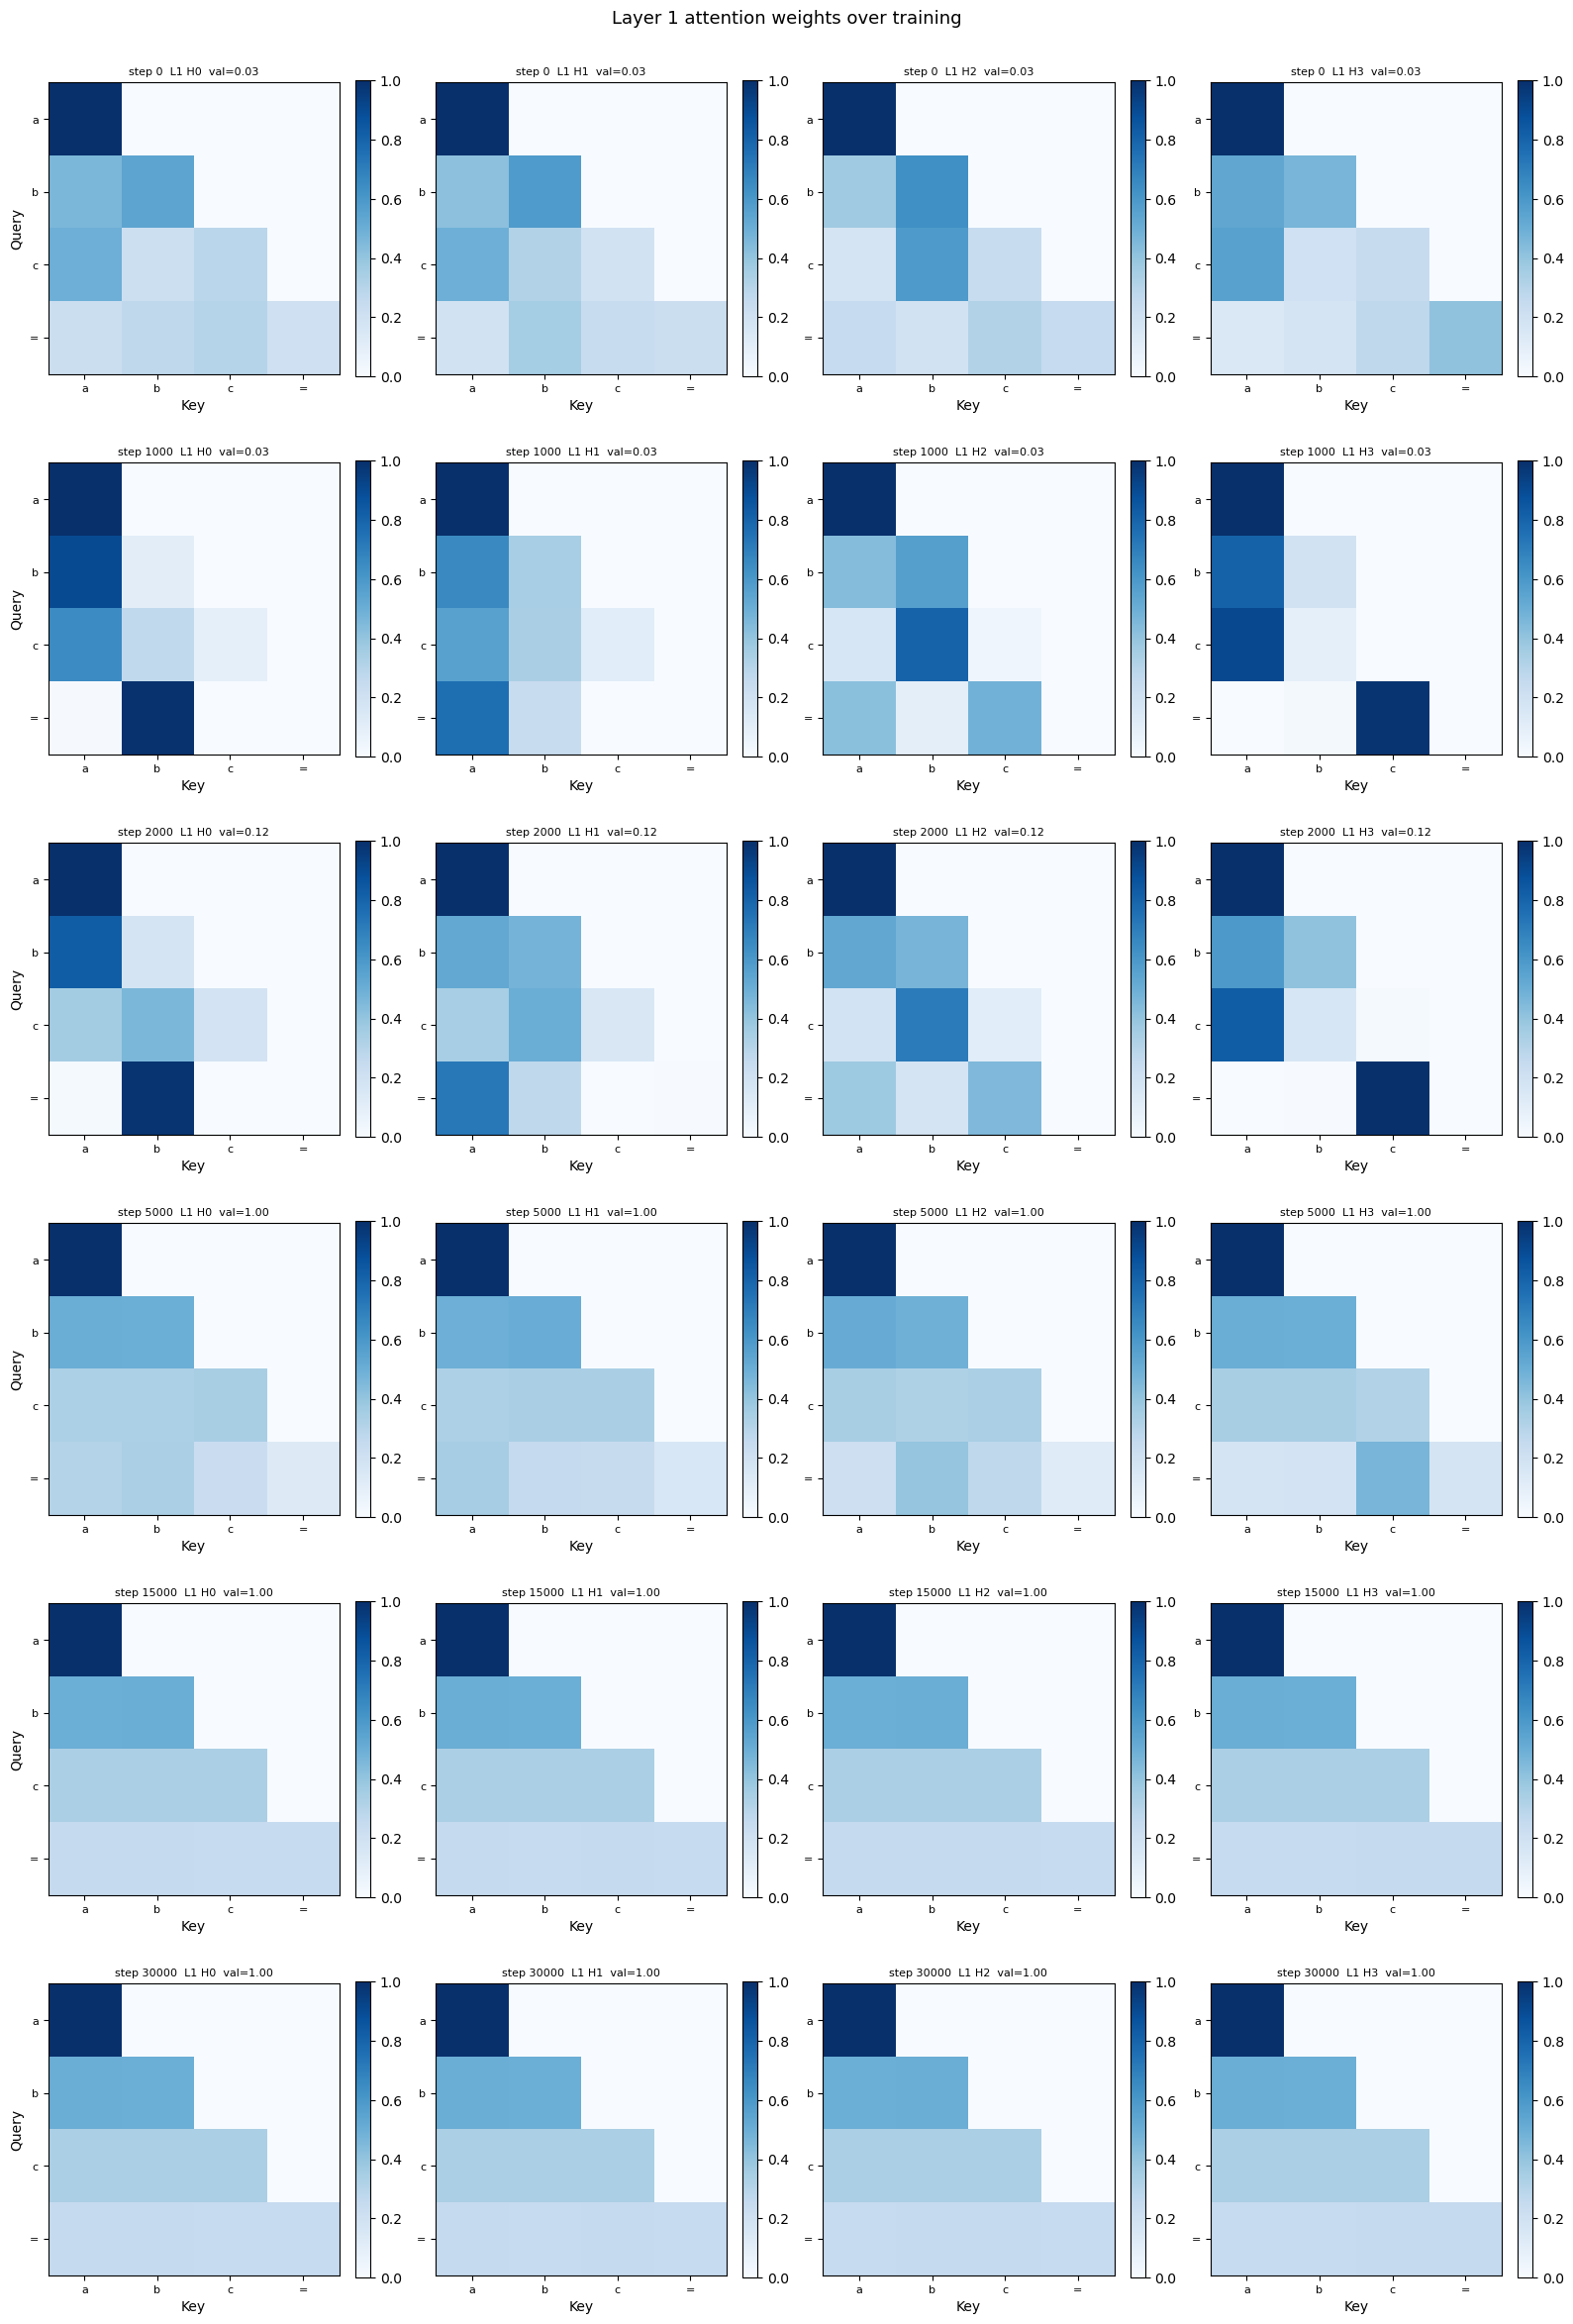

Cached attention shape:  torch.Size([512, 4, 4, 4])  layer  1


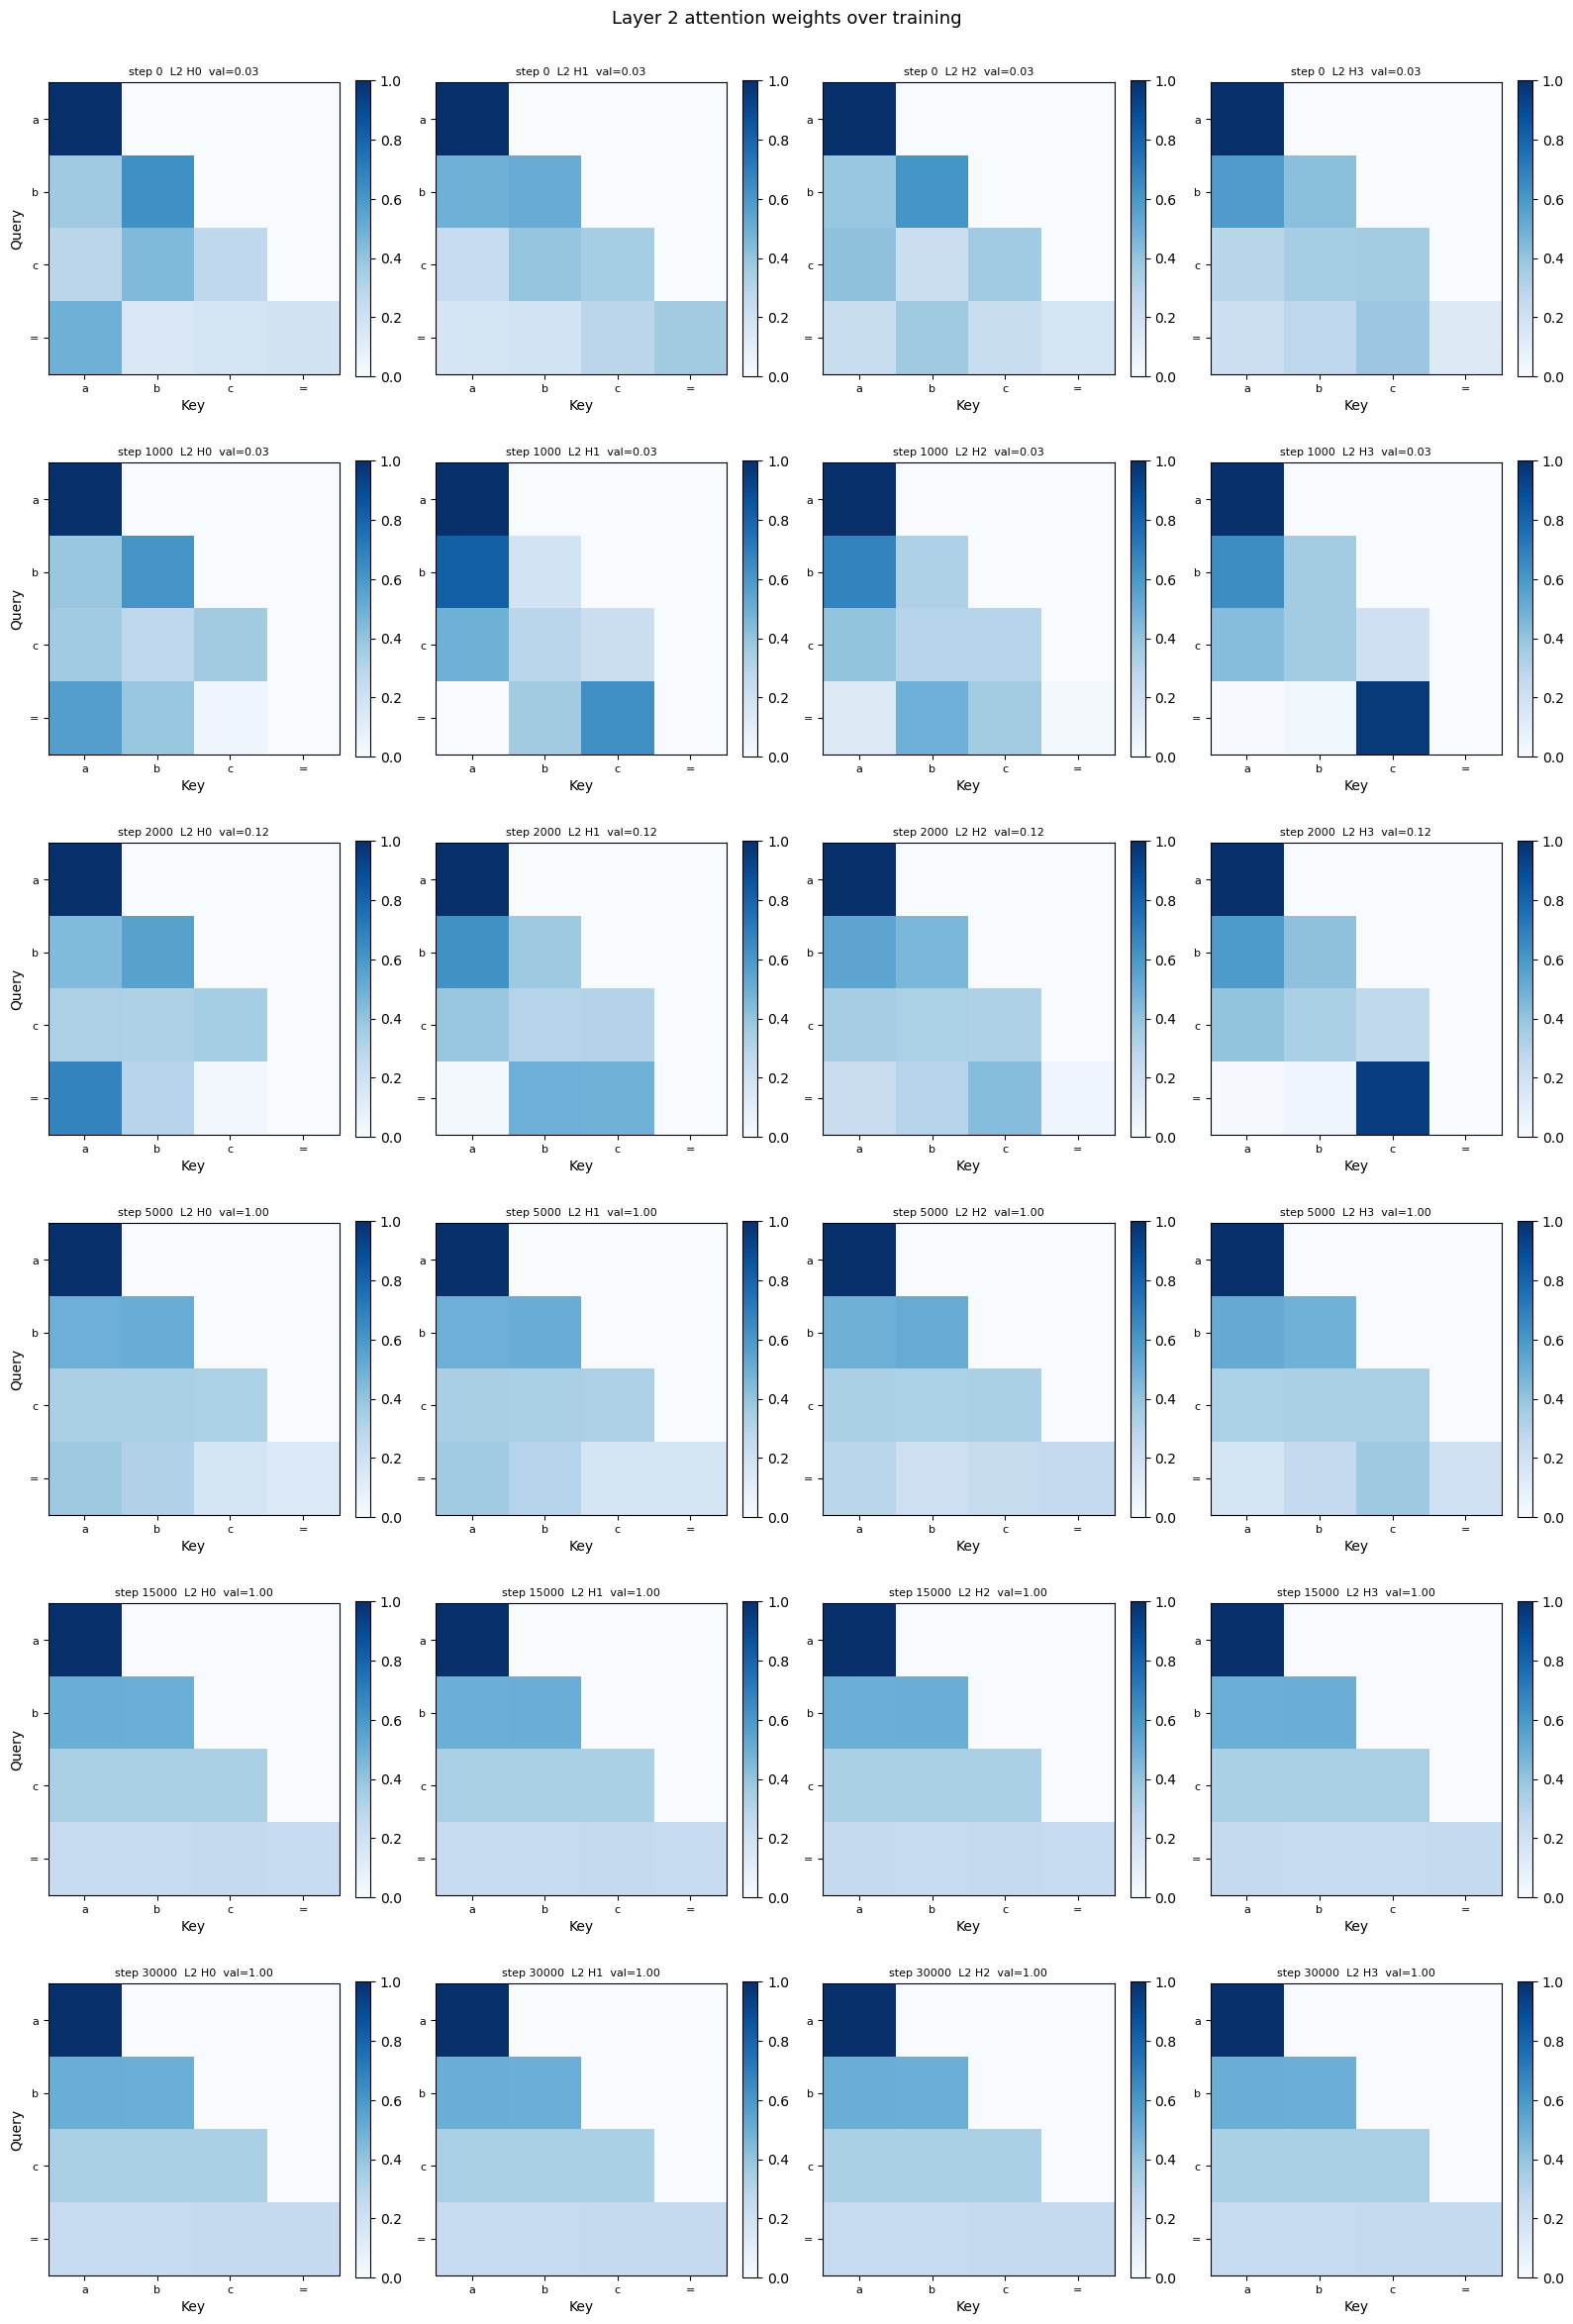

In [8]:
TOKEN_LABELS = ['a', 'b', 'c', '=']

def plot_attention_over_training(ckpts, layer_idx=0): #Takes in input the list of checkpoints and which layer to visualize.
    key = f'attn_weights_{layer_idx}' #Cache dictionary key to look for
    valid_ckpts = [c for c in ckpts if 'cache' in c and key in c['cache']] #Finds checkpoints with attention weights cached
    
    if not valid_ckpts:
        print(f'Key "{key}" not found in any checkpoint cache.'); return

    print("Cached attention shape: ",valid_ckpts[0]['cache'][key].shape, " layer ", layer_idx)
    n_heads   = valid_ckpts[0]['cache'][key].shape[1] #Reads the number of attention heads from the cache tensor shape [B, n_heads, T, T]
    
    n_ckpts   = len(valid_ckpts)
    fig, axes = plt.subplots(n_ckpts, n_heads, figsize=(4 * n_heads, 4 * n_ckpts))
    axes = np.array(axes).reshape(n_ckpts, n_heads) #One row per checkpoint, one column per attention head

    for row, ckpt in enumerate(valid_ckpts):
        A      = ckpt['cache'][key].numpy()   # [B, H, T, T]
        A_example = A[10,:,:,:] #Select one arbitrary example (an average would have smoothed things out articifially)
        T      = A_example.shape[-1] #Sequence lenght
        labels = TOKEN_LABELS[:T]
        h      = ckpt['history']
        
        for head in range(n_heads):
            #For each attention head, plot its 4x4 attention weight matrix as a heatmap
            ax = axes[row, head]
            im = ax.imshow(A_example[head], vmin=0, vmax=1, cmap='Blues') #vmin=0, vmax=1 fixes the colour scale since attention weights sum to 1 and are non-negative.
            
            ax.set_xticks(range(T)); ax.set_xticklabels(labels, fontsize=8)
            ax.set_yticks(range(T)); ax.set_yticklabels(labels, fontsize=8)
            ax.set_title(f"step {ckpt['step']}  L{layer_idx+1} H{head}  val={h['val_acc'][-1]:.2f}",
                         fontsize=8)
            if head == 0: ax.set_ylabel('Query')
            ax.set_xlabel('Key')
            plt.colorbar(im, ax=ax, fraction=0.046)

    plt.suptitle(f'Layer {layer_idx+1} attention weights over training', fontsize=13)
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.savefig(f'analysis_attn_layer{layer_idx+1}_all.png', dpi=150, bbox_inches='tight')
    plt.show()
    
KEY_STEPS = [0,1000,2000, 5000, 15000,30000]
key_ckpts_analysis = [c for c in ckpts if c['step'] in KEY_STEPS] #Selects only the checkpoints at specific steps of interest

plot_attention_over_training(key_ckpts_analysis, layer_idx=0)   # layer 1
plot_attention_over_training(key_ckpts_analysis, layer_idx=1)   # layer 2

#### Logit lens 
Applies the model's own LayerNorm + W_U (unembedding matrix) to intermediate residual streams
and measures whether the correct answer is already in output-readable format.

It differs from the Fourier probe: the probe fits a new linear function and tests
decodability in principle. The logit lens uses the model's actual decoder and
tests whether the representation is already in the specific format W_U expects.


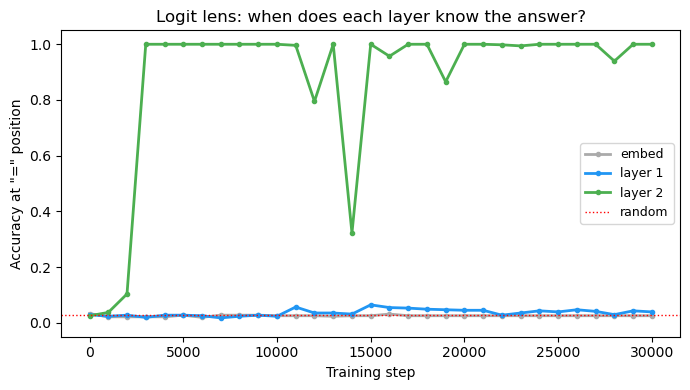

In [9]:
LAYER_KEYS    = ['embed', 'resid_post_0', 'resid_post_1']
LAYER_DISPLAY = ['embed', 'layer 1', 'layer 2']
LAYER_TITLES  = {lk: ld for lk, ld in zip(LAYER_KEYS, LAYER_DISPLAY)} #Dictionary mapping internal cache key names to names for plots
layer_colors = {'embed': '#aaaaaa', 'resid_post_0': '#2196F3', 'resid_post_1': '#4CAF50'}

def logit_lens_one_ckpt(ckpt):
    sd, cache, ref_x = ckpt['model_state_dict'], ckpt['cache'], ckpt['ref_inputs'] #unpacks the checkpoint
    p_local, n_inp   = ckpt['config']['p'], ckpt['config']['n_inputs']
    #From the saved state dictionary we extract the layer norm weights and unembedding matrix weights
    ln_w = sd['ln_f.weight'].float()
    ln_b = sd['ln_f.bias'].float()
    W_U  = sd['unembed.weight'].float()

    def apply_ln(h):
        #Manual implementation of layer norm. For each bectr in h, subtract its mean and divide by std
        #Then scale and shift using the learned parameters.
        mean = h.mean(dim=-1, keepdim=True)
        std  = h.std(dim=-1, keepdim=True, correction=0) + 1e-5
        return (h - mean) / std * ln_w + ln_b

    #We extract the 3 operand values from the input examples
    a = torch.as_tensor(ref_x[:, 0], dtype=torch.long)
    b = torch.as_tensor(ref_x[:, 1], dtype=torch.long)
    c = torch.as_tensor(ref_x[:, 2], dtype=torch.long)
    target_eq = (a + b + c) % p_local #Computes the correct answer for each cached example 

    results = {}
    for lk in LAYER_KEYS: #Ityerates over the 3 layers
        h_eq     = cache[lk].float()[:, -1, :] # last token: = position only
        logits   = apply_ln(h_eq) @ W_U.T  #Applies LayerNorm to the residual stream, then multiplies by transpose of unembedding matrix. 
        #Resulting shape [512,128] @ [128,37] = [512,37]
        preds    = logits.argmax(dim=-1) #takes the highest-scoring answer for each example
        acc      = (preds == target_eq).float().mean().item()
        results[lk] = acc
    return results

#run over all checkpoints
all_steps_ll = [c['step'] for c in ckpts]
ll_curves    = {lk: [] for lk in LAYER_KEYS}

for ckpt in ckpts:
    res = logit_lens_one_ckpt(ckpt)
    for lk in LAYER_KEYS:
        ll_curves[lk].append(res[lk])

fig, ax = plt.subplots(figsize=(7, 4))

for lk in LAYER_KEYS:
    ax.plot(all_steps_ll, ll_curves[lk],color=layer_colors[lk], marker='o', markersize=3,linewidth=2, label=LAYER_TITLES[lk])

ax.axhline(1 / ckpts[0]['config']['p'], color='red',
           linestyle=':', linewidth=1, label='random')
ax.set_xlabel('Training step')
ax.set_ylabel('Accuracy at "=" position')
ax.set_title('Logit lens: when does each layer know the answer?')
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('analysis_logit_lens.png', dpi=150, bbox_inches='tight')
plt.show()

### Linear probe for all frequencies 
Runs the Fourier linear probe at every frequency k=1..18 at resid_post_0,
pos =, target cos and sin of a+b+c mod 37, for each training checkpoint.\
Bars coloured red if R² > 0.5 (active), grey otherwise.\
Key finding: before grokking all frequencies are near zero or negative.\
At grokking some frequencies jump above 0.5 simultaneously.\
After grokking the active set gradually narrows, as weight decay continues compressing the weights.\

In [10]:
#These functions will be used for all linear probes

def ols_r2(H_tr, y_tr, H_te, y_te): # Fits a linear regression from residual stream vectors to a target scalar vector
    w, _, _, _ = np.linalg.lstsq(H_tr, y_tr, rcond=None) #lstsq solves the least squares problem: finds the weight vector w such that H_tr @ w best approximates y_tr
    y_pred = H_te @ w

    #Computes the R^2 on the held out test set
    ss_res = ((y_te - y_pred) ** 2).sum() #sum of squared residuals
    ss_tot = ((y_te - y_te.mean()) ** 2).sum() #Total variance of the target
    return float(1 - ss_res / ss_tot) if ss_tot > 1e-12 else 0.0

def freq_r2(H, labels, k, p, train_idx, test_idx):
    angle = 2 * np.pi * k * labels / p #For a given frequency k, computes the angle for each example
    #The angle maps each answer to its position on the kth circle
    cos_r2 = ols_r2(H[train_idx], np.cos(angle)[train_idx], H[test_idx],  np.cos(angle)[test_idx])
    sin_r2 = ols_r2(H[train_idx], np.sin(angle)[train_idx], H[test_idx],  np.sin(angle)[test_idx])
    #We have fit 2 separate linear probes, one predicting the cosine component, and one the sin at target frequency k
    #We return tehir sum, which is maximum 2
    return cos_r2 + sin_r2

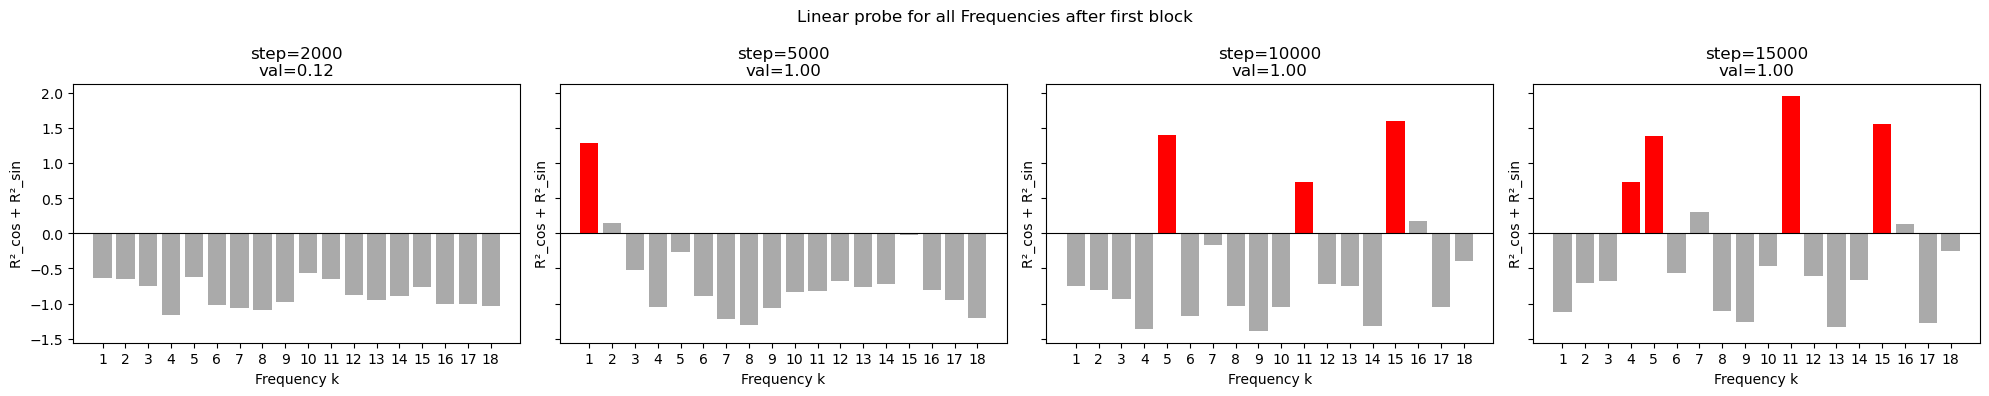

In [11]:
KEY_STEPS = [2000, 5000, 10000, 15000] #Select the epochs we want to see
key_ckpts_analysis = [c for c in ckpts if c['step'] in KEY_STEPS] #Selects only the checkpoints at specific steps of interest

#Fixed train/test split of the 512 cached examples, so the split is identical across runs and across checkpoints. 
rng   = np.random.default_rng(42)
idx   = rng.permutation(len(key_ckpts_analysis[0]['ref_inputs']))
split = int(0.8 * len(idx))
train_idx, test_idx = idx[:split], idx[split:]

fig, axes = plt.subplots(1, len(key_ckpts_analysis), figsize=(5 * len(key_ckpts_analysis), 4),sharey=True)

for ax, ckpt in zip(axes, key_ckpts_analysis):
    #For each checkpoint, we extract the residual stream at = position after layer 0
    H  = np.asarray(ckpt['cache']['resid_post_0'][:, -1, :], dtype=float) #shape [512, 128]
    y  = np.asarray(ckpt['ref_labels'], dtype=float)
    p  = ckpt['config']['p']

    r2s    = [freq_r2(H, y, k, p, train_idx, test_idx) for k in range(1, p // 2 + 1)] #Runs probe at every frequency
    colors = ['red' if v > 0.5 else '#aaaaaa' for v in r2s]

    ax.bar(range(1, p // 2 + 1), r2s, color=colors)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(f"step={ckpt['step']}\nval={ckpt['history']['val_acc'][-1]:.2f}")
    ax.set_xlabel('Frequency k')
    ax.set_ylabel('R²_cos + R²_sin')
    ax.set_xticks(range(1, p // 2 + 1))

plt.suptitle('Linear probe for all Frequencies after first block',
             fontsize=12)
plt.tight_layout()
plt.savefig('analysis_freq_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

### Fourier linear probe at key frequencies 
For each checkpoint, we fit a linear probe from the residual stream to
$cos(2\pi kt/p)$ and $sin(2\pi kt/p)$ for 2 key frequencies and 2 non key frequencies at every (layer, position).\
Reports $R^2cos$ + $R^2sin$ (max = 2.0 = perfect encoding).

This tells us where and when in the network during training each target value becomes linearly decodable.
If the model uses frequency k to represent values, the residual stream should linearly predict $cos(2\pi kt/p)$ and $sin(2\pi kt/p)$.

Before running this cell, one needs to look at the main frequencies found in the plots above and decide which ones to test for.


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  step=  2000   val_acc=0.117
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  ── embed ──
  target    pos  k=11  k= 1  k=15  k=13
  ──────────────────────────────────────────────────
  a           a    2.000    2.000    2.000    2.000
  a           b   -0.183   -0.230   -0.290   -0.026
  a           c   -0.145   -0.207    0.054   -0.189
  a           =   -0.030   -0.020   -0.008   -0.008

  b           a   -0.306   -0.308   -0.034   -0.177
  b           b    2.000    2.000    2.000    2.000
  b           c   -0.234   -0.381   -0.219   -0.316
  b           =   -0.064   -0.017   -0.016   -0.016

  c           a   -0.364   -0.215   -0.212   -0.183
  c           b   -0.210   -0.441   -0.140   -0.262
  c           c    2.000    2.000    2.000    2.000
  c           =   -0.019   -0.014   -0.007   -0.008

  a+b         a   -0.237   -0.303   -0.054   -0.177
  a+b         b   -0.149   -0.230   

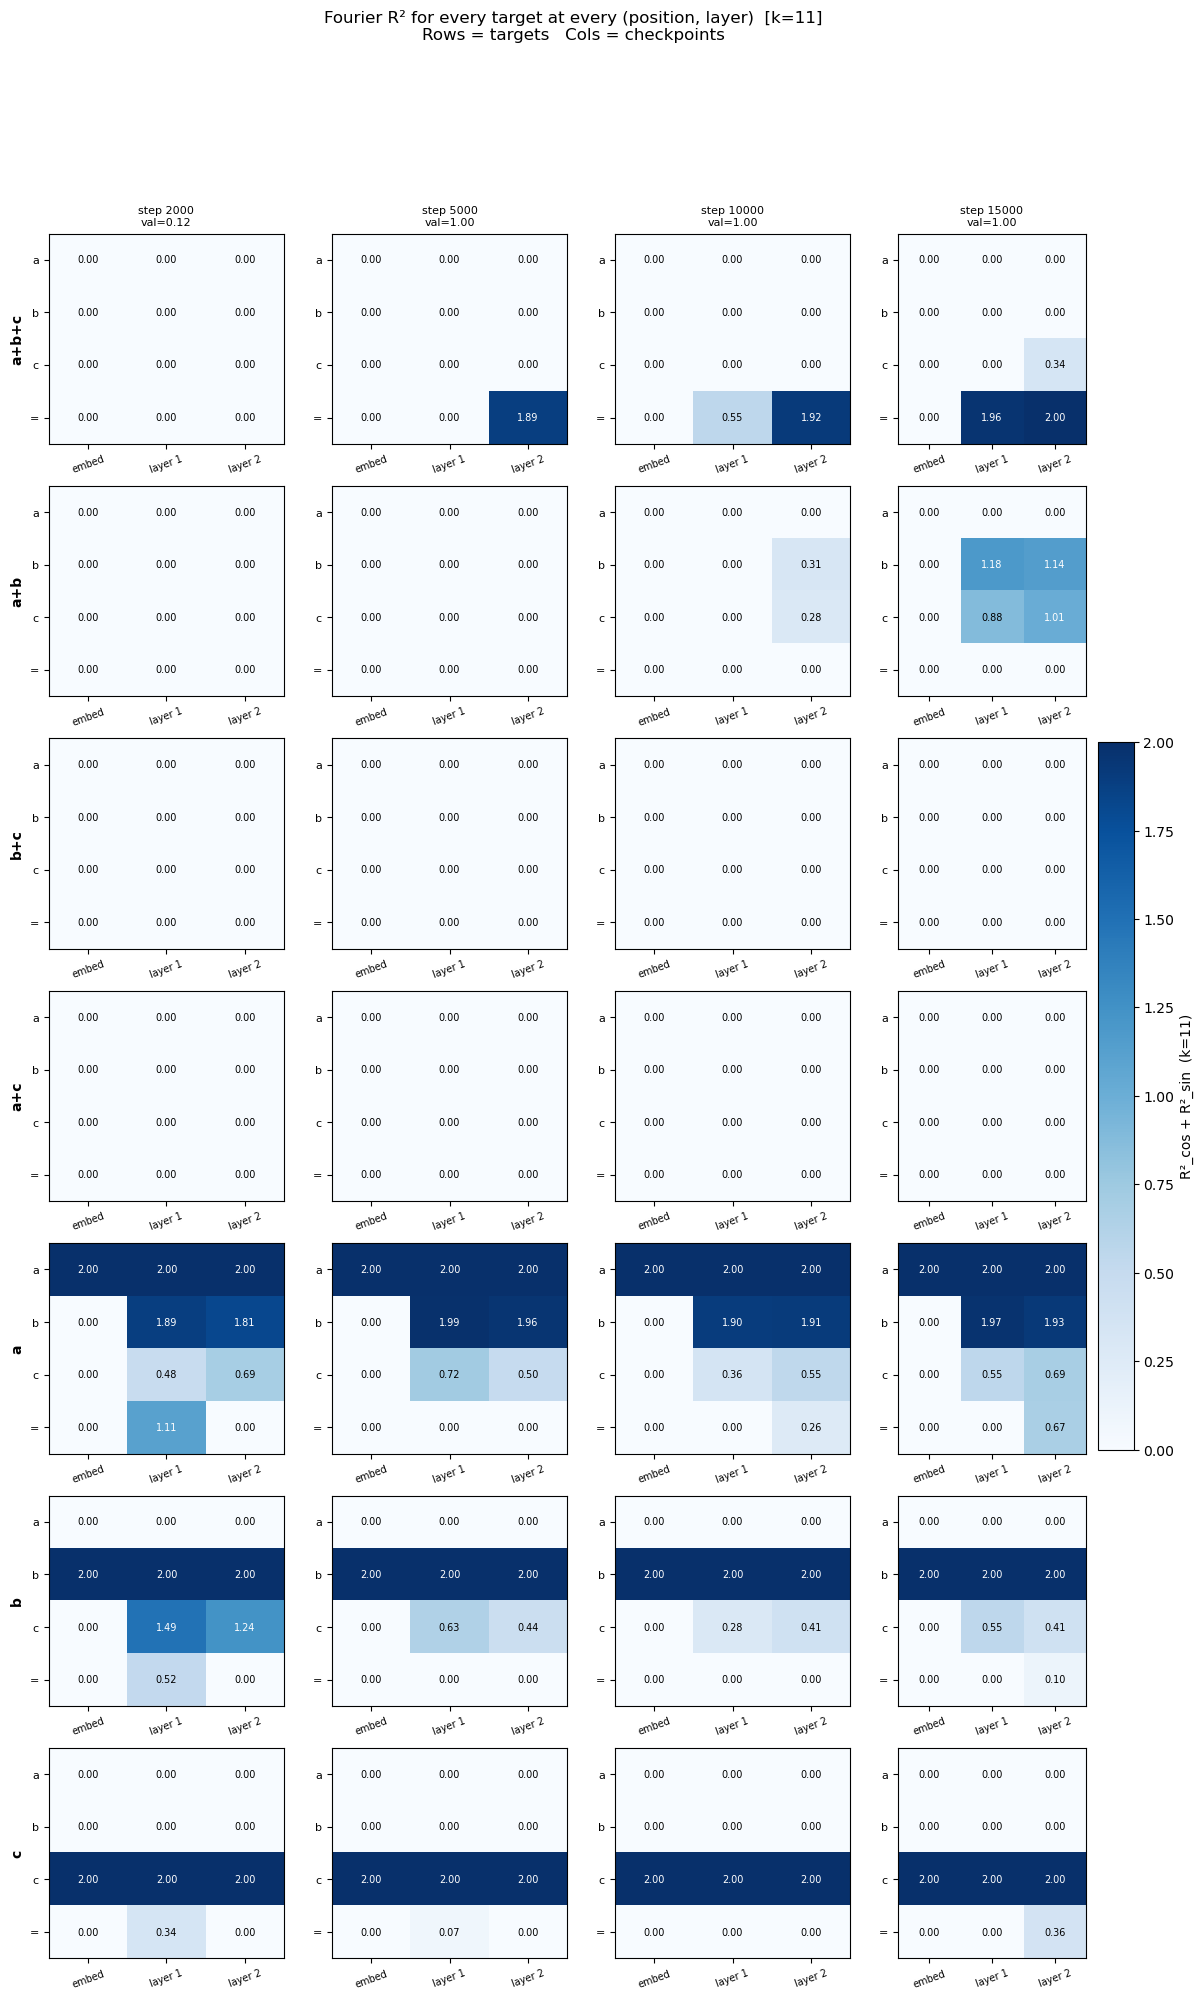

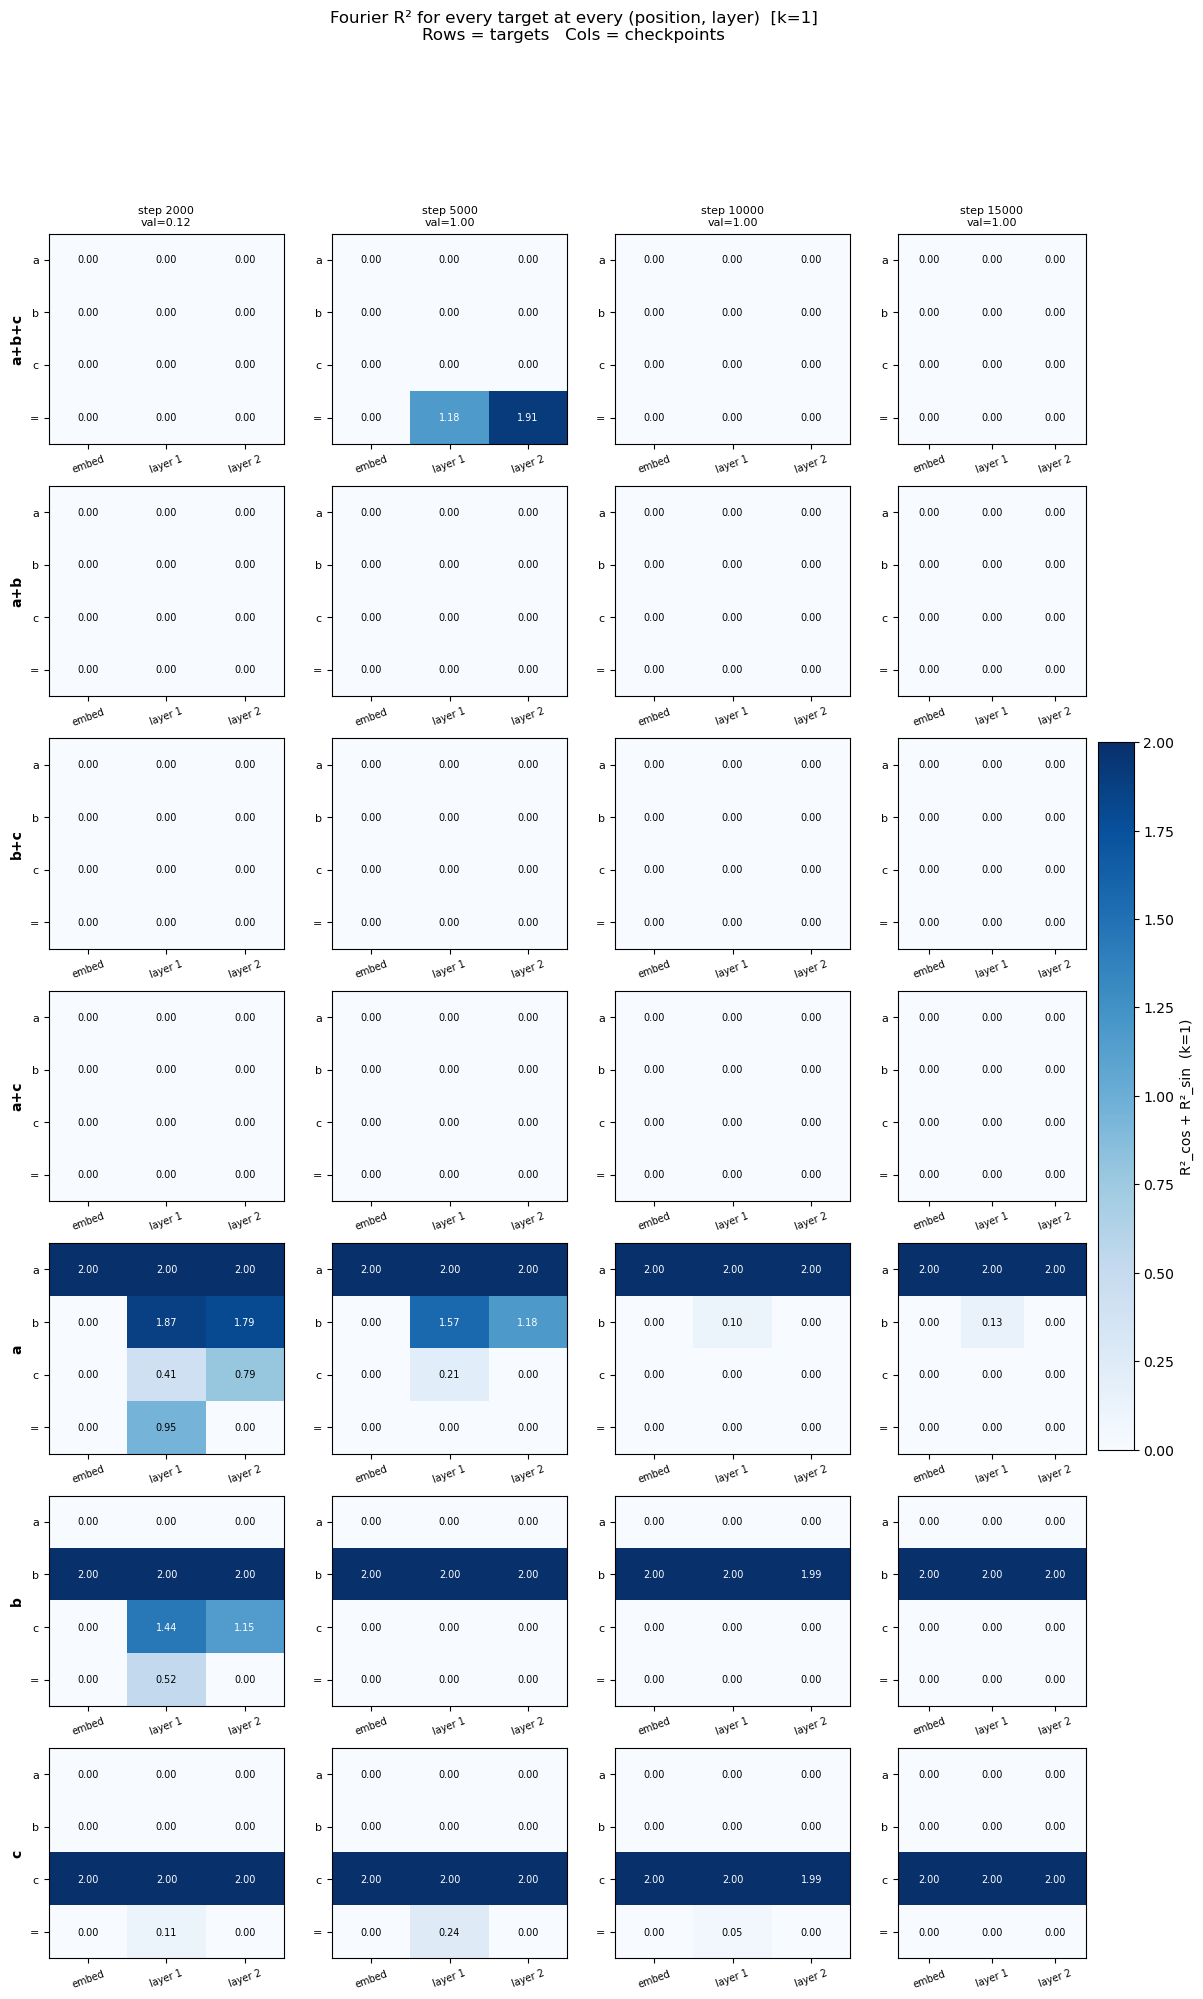

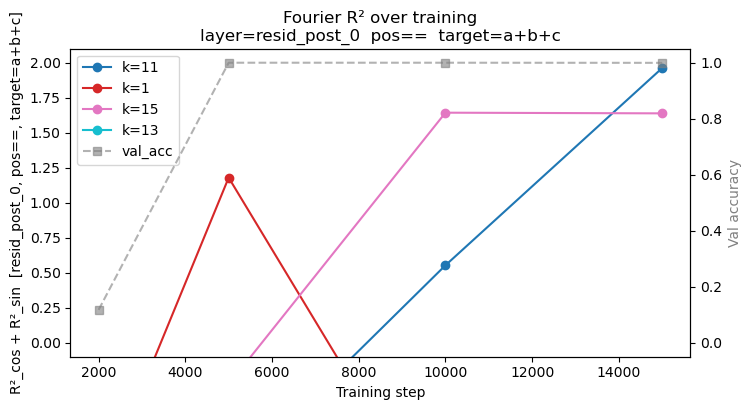

In [12]:
FREQS         = [11, 1,15, 13] # Fourier frequencies to probe, we chose 2 key frequencies and 2 frequencies that stay negative, all from the plot above
POS_LABELS    = ['a', 'b', 'c', '=']
LAYER_KEYS    = ['embed', 'resid_post_0', 'resid_post_1']
LAYER_DISPLAY = ['embed', 'layer 1', 'layer 2']
RANDOM_SEED   = 29 

key_ckpts_analysis = [c for c in ckpts if c['step'] in KEY_STEPS]

def probe_checkpoint(ckpt, train_idx, test_idx):
    cache = ckpt['cache']
    ref_x = ckpt['ref_inputs'] 
    p     = ckpt['config']['p']
    n_inp = ckpt['config']['n_inputs']  # 3 for a+b+c

    #Extracts the three operand values from the cached inputs
    a = np.asarray(ref_x[:, 0], dtype=float)
    b = np.asarray(ref_x[:, 1], dtype=float)
    c = np.asarray(ref_x[:, 2], dtype=float)

    #We define what targets we want to probe
    targets = {
        #sanity checks, the embeddings should decode them perfectly 
        'a':     a % p, 
        'b':     b % p,
        'c':     c % p,
        #Partial sums test
        'a+b':   (a + b) % p,
        'b+c':   (b + c) % p,
        'a+c':   (a + c) % p,
        #Full result
        'a+b+c': (a + b + c) % p,
    }

    pos_labels = POS_LABELS[:n_inp + 1]   # ['a', 'b', 'c', '=']
    results    = {}

    val_acc = ckpt['history']['val_acc'][-1]
    print(f"\n{'━'*72}")
    print(f"  step={ckpt['step']:>6}   val_acc={val_acc:.3f}")
    print(f"{'━'*72}")

    for lk in LAYER_KEYS: #Iterates over the 3 layers
        full_resid  = np.asarray(cache[lk])   # [B, T, d]
        results[lk] = {}

        col_headers = "  ".join(f"k={k:>2}" for k in FREQS)
        print(f"\n  ── {lk} ──")
        print(f"  {'target':<8}  {'pos':>3}  {col_headers}")
        print(f"  {'─'*50}")

        for tname, tvals in targets.items():
            results[lk][tname] = {}
            for pos_idx, pos_label in enumerate(pos_labels): #Double loop over all targets and positions
                H = full_resid[:, pos_idx, :]   # [B, d]
                results[lk][tname][pos_label] = {}
                row_vals = []
                for k in FREQS: #For each frequency in the list, runs the probe and stores the result. 
                    r2 = freq_r2(H, tvals, k, p, train_idx, test_idx)
                    results[lk][tname][pos_label][k] = r2
                    row_vals.append(r2)
                freq_str = "  ".join(f"{v:>7.3f}" for v in row_vals)
                print(f"  {tname:<8}  {pos_label:>3}  {freq_str}")
            print()

    return results


#fixed train/test split (shared across all checkpoints)
n          = len(key_ckpts_analysis[0]['ref_inputs'])
rng        = np.random.default_rng(RANDOM_SEED)
idx        = rng.permutation(n)
split      = int(0.8 * n)
train_idx  = idx[:split]
test_idx   = idx[split:]

all_results = {}
for ckpt in key_ckpts_analysis:
    all_results[ckpt['step']] = probe_checkpoint(ckpt, train_idx, test_idx)


#Plotting function that makes a 2D matrix of shape [n_pos, n_layers] for one target and frequency
#Negative R^2 values are clipped for the heatmap
def make_matrix(res_step, target_name, pos_labels, freq):
    return np.array([[max(0.0, res_step[lk][target_name][pos][freq]) for lk in LAYER_KEYS]for pos in pos_labels])

#First selected frequency
freq        = FREQS[0]
n_inp       = key_ckpts_analysis[0]['config']['n_inputs']
pos_labels  = POS_LABELS[:n_inp + 1]
sorted_steps = sorted(all_results.keys())
val_acc_map  = {c['step']: c['history']['val_acc'][-1] for c in ckpts}

# One row of heatmaps per target, one col per checkpoint.
targets_to_plot = ['a+b+c', 'a+b', 'b+c', 'a+c', 'a', 'b', 'c']
nrows, ncols     = len(targets_to_plot), len(sorted_steps)

fig, axes = plt.subplots(nrows, ncols,figsize=(3.5 * ncols, 3.2 * nrows))
axes = np.array(axes).reshape(nrows, ncols)

im = None
for row, tname in enumerate(targets_to_plot):
    for col, step in enumerate(sorted_steps):
        ax  = axes[row, col]
        mat = make_matrix(all_results[step], tname, pos_labels, freq)
        im  = ax.imshow(mat, vmin=0, vmax=2, cmap='Blues', aspect='auto')
        ax.set_xticks(range(len(LAYER_KEYS)))
        ax.set_xticklabels(LAYER_DISPLAY, fontsize=7, rotation=20)
        ax.set_yticks(range(len(pos_labels)))
        ax.set_yticklabels(pos_labels, fontsize=8)
        if col == 0:
            ax.set_ylabel(tname, fontsize=10, fontweight='bold')
        if row == 0:
            ax.set_title(f'step {step}\nval={val_acc_map[step]:.2f}', fontsize=8)
        for i in range(len(pos_labels)):
            for j in range(len(LAYER_KEYS)):
                ax.text(j, i, f'{mat[i, j]:.2f}',
                        ha='center', va='center', fontsize=7,
                        color='white' if mat[i, j] > 1.0 else 'black')

plt.colorbar(im, ax=axes[:, -1].tolist(),label=f'R²_cos + R²_sin  (k={freq})')
plt.suptitle(f'Fourier R² for every target at every (position, layer)  [k={freq}]\n''Rows = targets   Cols = checkpoints',fontsize=12)
#plt.tight_layout()
plt.savefig('analysis_all_targets_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

#Second selected frequency
freq        = FREQS[1]
n_inp       = key_ckpts_analysis[0]['config']['n_inputs']
pos_labels  = POS_LABELS[:n_inp + 1]
sorted_steps = sorted(all_results.keys())
val_acc_map  = {c['step']: c['history']['val_acc'][-1] for c in ckpts}

# One row of heatmaps per target, one col per checkpoint.
targets_to_plot = ['a+b+c', 'a+b', 'b+c', 'a+c', 'a', 'b', 'c']
nrows, ncols     = len(targets_to_plot), len(sorted_steps)

fig, axes = plt.subplots(nrows, ncols,figsize=(3.5 * ncols, 3.2 * nrows))
axes = np.array(axes).reshape(nrows, ncols)

im = None
for row, tname in enumerate(targets_to_plot):
    for col, step in enumerate(sorted_steps):
        ax  = axes[row, col]
        mat = make_matrix(all_results[step], tname, pos_labels, freq)
        im  = ax.imshow(mat, vmin=0, vmax=2, cmap='Blues', aspect='auto')
        ax.set_xticks(range(len(LAYER_KEYS)))
        ax.set_xticklabels(LAYER_DISPLAY, fontsize=7, rotation=20)
        ax.set_yticks(range(len(pos_labels)))
        ax.set_yticklabels(pos_labels, fontsize=8)
        if col == 0:
            ax.set_ylabel(tname, fontsize=10, fontweight='bold')
        if row == 0:
            ax.set_title(f'step {step}\nval={val_acc_map[step]:.2f}', fontsize=8)
        for i in range(len(pos_labels)):
            for j in range(len(LAYER_KEYS)):
                ax.text(j, i, f'{mat[i, j]:.2f}',
                        ha='center', va='center', fontsize=7,
                        color='white' if mat[i, j] > 1.0 else 'black')

plt.colorbar(im, ax=axes[:, -1].tolist(),label=f'R²_cos + R²_sin  (k={freq})')
plt.suptitle(f'Fourier R² for every target at every (position, layer)  [k={freq}]\n''Rows = targets   Cols = checkpoints',fontsize=12)
#plt.tight_layout()
plt.savefig('analysis_all_targets_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


#R^2 over time at (resid_post_0, pos=, target=a+b+c), shows when the Fourier circuit snaps in relative to grokking.
target_ot = 'a+b+c'
layer_ot  = 'resid_post_0'
pos_ot    = '='

fig, ax1 = plt.subplots(figsize=(8, 4))
ax2 = ax1.twinx()

for color, k in zip(plt.cm.tab10(np.linspace(0, 1, len(FREQS))), FREQS):
    r2s = [all_results[s][layer_ot][target_ot][pos_ot][k] for s in sorted_steps]
    ax1.plot(sorted_steps, r2s, marker='o', label=f'k={k}', color=color)

ax2.plot(sorted_steps, [val_acc_map[s] for s in sorted_steps],
         marker='s', linestyle='--', color='grey', alpha=0.6, label='val_acc')

ax1.set_xlabel('Training step')
ax1.set_ylabel(f'R²_cos + R²_sin  [{layer_ot}, pos={pos_ot}, target={target_ot}]')
ax2.set_ylabel('Val accuracy', color='grey')
ax1.set_ylim(-0.1, 2.1)
ax2.set_ylim(-0.05, 1.05)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
ax1.set_title(f'Fourier R² over training\n' f'layer={layer_ot}  pos={pos_ot}  target={target_ot}')
#plt.tight_layout()
plt.savefig('analysis_r2_over_time.png', dpi=150, bbox_inches='tight')
plt.show()


#### Activation patching 
Causal intervention: we take a clean input (a,b,c) and a corrupted input (a',b,c)
differing only in a, then patch the residual stream at one position from the
corrupt run into the clean run and measures whether the output flips to (a'+b+c)%p.
Patching pos =: should flip the output completely (acc_corrupt becomes 1.0)
Patching pos a/b/c: should not flip the output (acc_corrupt stays near 0)

This is the test between direct vs staged computation.
If patching b flipped the output, layer 0 would be routing a's contribution
through position b.

In [13]:
def build_model(ckpt): #Reconstruct the model because we will need to run a forward pass
    cfg = ckpt['config'] #Reads the architecture hyperparameters from ckpt['config']
    model = GrokTransformer(
        p        = cfg['p'],
        n_inputs = cfg['n_inputs'],
        d_model  = cfg['d_model'],
        n_heads  = cfg['n_heads'],
        n_layers = cfg['n_layers'],
        d_ff     = cfg['d_ff'],
        causal   = cfg['causal'],
    )
    model.load_state_dict(ckpt['model_state_dict']) #loads the saved weights with load_state_dict
    model.eval()
    return model


def patching(ckpt, n_pairs=500, device='cpu'):
    # Run the same patch experiment on all positions to see which one
    # causally carries a's contribution after layer 0.
    print(f"\n{'━'*60}")
    print(f"step={ckpt['step']}  val_acc={ckpt['history']['val_acc'][-1]:.3f}")
    print(f"{'━'*60}")
    print(f"  {'patch pos':<12}  {'effect':>8}  {'acc_corrupt':>12}  {'acc_clean':>10}")
    print(f"  {'─'*50}")

    model = build_model(ckpt)
    model.to(device)
    model.eval()

    ref_x = ckpt['ref_inputs']
    p     = ckpt['config']['p']
    B     = len(ref_x)

    # build clean and corrupt pairs: same b and c, different a
    rng        = np.random.default_rng(0)
    idx        = rng.integers(0, B, size=n_pairs)
    clean_np   = np.asarray(ref_x[idx])
    corrupt_np = clean_np.copy()
    new_a      = (clean_np[:, 0] + rng.integers(1, p, size=n_pairs)) % p  # offset in [1,p-1] guarantees a' != a
    corrupt_np[:, 0] = new_a

    clean_answers   = (clean_np[:, 0] + clean_np[:, 1] + clean_np[:, 2]) % p
    corrupt_answers = (new_a          + clean_np[:, 1] + clean_np[:, 2]) % p
    clean_t_ans     = torch.tensor(clean_answers,   dtype=torch.long)
    corrupt_t_ans   = torch.tensor(corrupt_answers, dtype=torch.long)

    clean_t   = torch.tensor(clean_np,   dtype=torch.long, device=device)
    corrupt_t = torch.tensor(corrupt_np, dtype=torch.long, device=device)

    # forward pass: get resid_post_0 for both runs
    # stop before layer 1 so we can patch and re-run from there
    def get_resid(x):
        with torch.no_grad():
            h = model.token_emb(x) + model.pos_emb(
                    torch.arange(x.size(1), device=device))
            return model.blocks[0](h)

    resid_clean   = get_resid(clean_t)    # [n_pairs, 4, 128]
    resid_corrupt = get_resid(corrupt_t)  # [n_pairs, 4, 128]

    results = {}
    pos_names = ['a', 'b', 'c', '=']
    for pos_idx, pos_name in enumerate(pos_names):
        # patching: replace one position's vectors with the corrupt version,
        # leave all other positions from the clean run unchanged
        patched = resid_clean.clone()
        patched[:, pos_idx, :] = resid_corrupt[:, pos_idx, :]

        # run layer 1 + ln_f + unembed on patched residual
        with torch.no_grad():
            h      = model.blocks[1](patched)
            logits = model.unembed(model.ln_f(h)[:, -1])  # [n_pairs, 37]

        preds       = logits.argmax(dim=-1).cpu()
        lc          = logits[torch.arange(n_pairs), clean_t_ans]
        lp          = logits[torch.arange(n_pairs), corrupt_t_ans]
        effect      = (lp - lc).mean().item()  # positive = pushed toward corrupt answer
        acc_corrupt = (preds == corrupt_t_ans).float().mean().item()
        acc_clean   = (preds == clean_t_ans).float().mean().item()

        results[pos_name] = {'effect': effect, 'acc_corrupt': acc_corrupt, 'acc_clean': acc_clean}
        print(f"  {pos_name:<12}  {effect:>+8.3f}  {acc_corrupt:>12.3f}  {acc_clean:>10.3f}")

    return results


patch_results = {}
for ckpt in key_ckpts_analysis:
    patch_results[ckpt['step']] = patching(ckpt)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
step=2000  val_acc=0.117
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  patch pos       effect   acc_corrupt   acc_clean
  ──────────────────────────────────────────────────
  a               -0.196         0.052       0.050
  b               -1.799         0.030       0.124
  c               -1.778         0.024       0.130
  =               +1.330         0.136       0.030

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
step=5000  val_acc=1.000
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  patch pos       effect   acc_corrupt   acc_clean
  ──────────────────────────────────────────────────
  a               -3.640         0.098       0.512
  b              -10.248         0.000       1.000
  c              -10.255         0.000       1.000
  =               +3.567         0.532       0.088

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
step=10000  val_acc=1.000
